In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
iris = load_iris()
X = iris.data

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
X_scaled.shape

(150, 4)

In [5]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

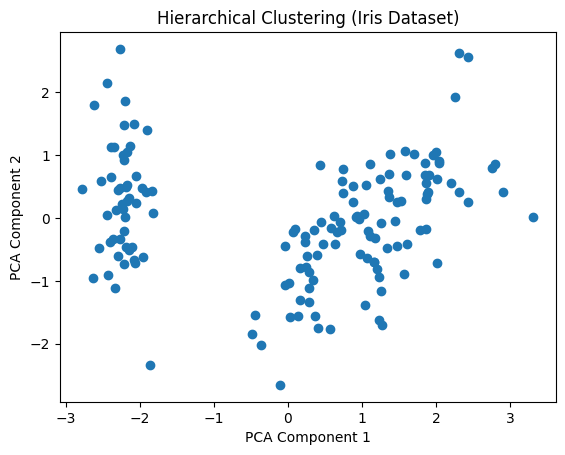

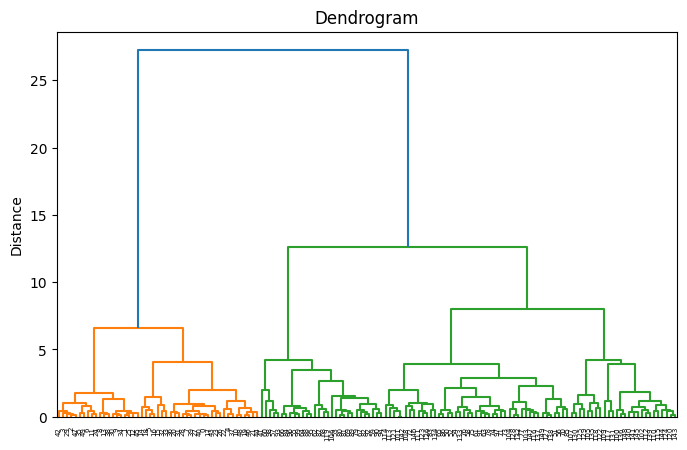

In [10]:
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.title("Hierarchical Clustering (Iris Dataset)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

linked = linkage(X_scaled, method='ward', metric='euclidean')

plt.figure(figsize=(8, 5))
dendrogram(linked)
plt.title("Dendrogram")
plt.ylabel("Distance")
plt.show()

In [8]:
model = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = model.fit_predict(X_pca)

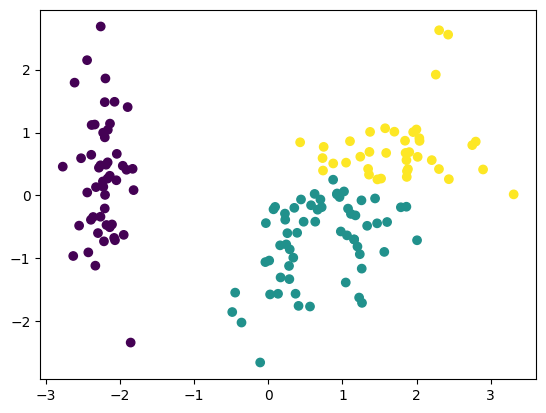

In [11]:
fig = plt.figure(0)
plt.scatter(X_pca[:,0],X_pca[:,1],c=labels)
plt.show()

K = 2, Silhouette Score = 0.615
K = 3, Silhouette Score = 0.511
K = 4, Silhouette Score = 0.449
K = 5, Silhouette Score = 0.404
K = 6, Silhouette Score = 0.367
K = 7, Silhouette Score = 0.371
K = 8, Silhouette Score = 0.393
K = 9, Silhouette Score = 0.418


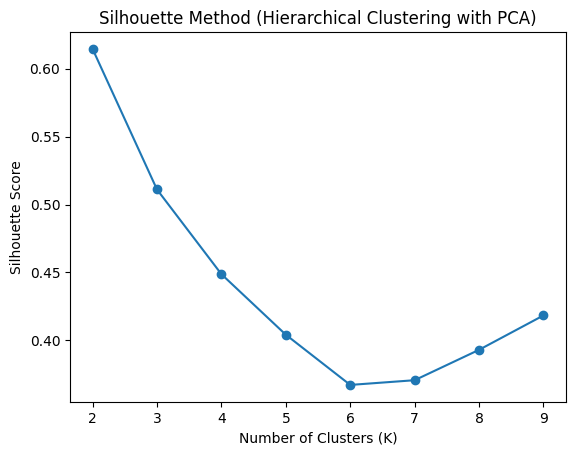

In [13]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

sil_scores = []
K = range(2, 10)

for k in K:
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(X_pca)   
    
    score = silhouette_score(X_pca, labels)
    sil_scores.append(score)

for k, score in zip(K, sil_scores):
    print(f"K = {k}, Silhouette Score = {score:.3f}")

# Plot graph
plt.plot(K, sil_scores, marker='o')
plt.title("Silhouette Method (Hierarchical Clustering with PCA)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.show()

Final model training after getting best Value of K

In [17]:
final_model = AgglomerativeClustering(n_clusters=2, linkage='ward')
final_labels = final_model.fit_predict(X_pca)

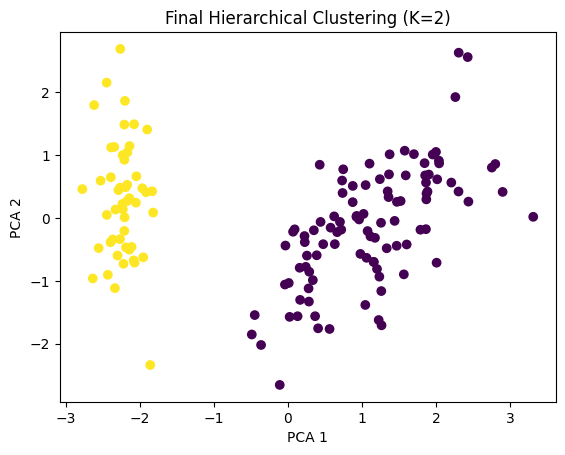

In [18]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=final_labels)
plt.title(f"Final Hierarchical Clustering (K=2)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()